# DSI: emulate, validate, then condition

_History matching in seconds, instead of days._


Every notebook so far has paid the model's full price. Building it (["build the model"](../part1_01_build_model/dizon_build_model.ipynb)), setting up the parameters (["PstFrom setup"](../part1_02_pstfrom_setup/dizon_pstfrom_setup.ipynb)), choosing the weights and the synthetic truth (["observations, weights and truth"](../part1_03_obs_weights_and_truth/dizon_obs_weights_and_truth.ipynb)), and running the prior Monte Carlo (["prior Monte Carlo"](../part1_04_prior_mc/dizon_prior_mc.ipynb)) — all of it rests on running DIZON, and DIZON costs ~6 min per run. The prior ensemble alone was 201 of those runs.

That is the wall this whole curriculum is built against. A history match with PESTPP-IES needs several iterations of a few hundred runs each; for a ~6 min model that is days of compute for a single forecast. We cannot afford to do that every time the question changes.


**Data Space Inversion (DSI)** is the way around the wall. Instead of history-matching the model, we history-match a cheap statistical *emulator* built from runs we have already paid for. The prior Monte Carlo gave us 201 realisations of the model's outputs; DSI learns the joint behaviour of those outputs directly in observation space, and can then be conditioned on data in seconds. No new DIZON runs.

The discipline of this notebook is one rule, stated up front and obeyed every time: **never trust an emulator you have not tested.** So the order is

1. finalise the synthetic truth and hold it out of training;
2. train DSI and **check its fidelity first** on realisations it never saw;
3. only then condition it with PESTPP-IES;
4. read off the payoff — the prior vs posterior forecast distribution, and the compute bill.


### Admin

We need `pyemu` and `flopy` from the vendored `dependencies/` tree (so the DSI emulator and the corrected runstor forward-run code are the ones this curriculum was written against), plus `herebedragons` for the binary helper. Everything is run from inside this notebook's own directory.


In [1]:
import os
import shutil
import warnings
warnings.filterwarnings("ignore")
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import psutil

import sys
import pyemu
import flopy
assert "dependencies" in flopy.__file__
assert "dependencies" in pyemu.__file__
sys.path.insert(0, "..")
import herebedragons as hbd

from pyemu.emulators import DSI

<frozen importlib._bootstrap>:488: DeprecationWarning: builtin type SwigPyPacked has no __module__ attribute
<frozen importlib._bootstrap>:488: DeprecationWarning: builtin type SwigPyObject has no __module__ attribute


**Prerequisite check.** This notebook consumes two upstream products, and treats them differently *by design*:

- the **prior Monte Carlo ensemble** from ["prior Monte Carlo"](../part1_04_prior_mc/dizon_prior_mc.ipynb) is a hard prerequisite — there is nothing to emulate without it, so the cell below resolves the prior MC source in the canonical order — the tracked, thinned `prebaked/prior_mc_obs_ensemble.jcb` artifact first, then a full prior MC you ran into the repo-root `master_priormc` — and **raises** with a pointer to that notebook if neither is found. The prior MC results are a tracked, thinned `prebaked/` artifact — running 201 DIZON realisations took roughly 1.6 h across 10 workers on a MacBook (~6 min/run in serial), so we load them rather than re-running.
- the **synthetic truth** from ["observations, weights and truth"](../part1_03_obs_weights_and_truth/dizon_obs_weights_and_truth.ipynb) is *not* a file we read back. As that notebook says explicitly, it **stages the selection criterion and defers the actual pick to here**, because the criterion needs the prior forecast distribution, which only exists once `part1_04` has run. So we deliberately re-apply the part1_03 criterion below rather than load a truth file — keeping the sequence strictly ordered, with no notebook depending on outputs of a later one.


In [2]:
# resolve the prior Monte Carlo source, with the canonical preference order:
#   1. the tracked, thinned prebaked obs ensemble (../../prebaked/prior_mc_obs_ensemble.jcb)
#   2. a full prior MC you ran yourself into the repo-root master dir (../../master_priormc)
# part1_04 uses the same order; we need a control file + tdis here, so we read those from
# whichever master directory carries them (the prebaked .jcb ships its companion pst).
prebaked_oe = Path("..") / ".." / "prebaked" / "prior_mc_obs_ensemble.jcb"
pmc_d = Path("..") / ".." / "master_priormc"

if prebaked_oe.exists() and (prebaked_oe.parent / "pest.pst").exists():
    # the prebaked artifact and its companion control file
    pmc_d = prebaked_oe.parent
    pst = pyemu.Pst(str(pmc_d / "pest.pst"))
    prior_oe_path = prebaked_oe   # named artifact; loaded with from_binary below
    print(f"loaded prebaked prior MC control file from {pmc_d}")
elif (pmc_d / "pest.pst").exists():
    # fall back to the full prior MC master dir produced during development
    pst = pyemu.Pst(str(pmc_d / "pest.pst"))
    prior_oe_path = None   # a live master dir; use the pst.ies.obsen accessor below
    print(f"loaded prior MC control file from {pmc_d}")
else:
    raise Exception(
        "you need to run the '../part1_04_prior_mc/dizon_prior_mc.ipynb' notebook "
        "(prior Monte Carlo results not found at the prebaked artifact "
        f"'{prebaked_oe}' or the master dir '{pmc_d}')")

loaded prebaked prior MC control file from ../../prebaked


In [3]:
# The synthetic truth is picked here, not loaded. By design, part1_03 stages the
# selection *criterion* (a realisation from the upper quartile of the prior forecast
# distribution) but defers the actual pick to this notebook, because the criterion
# needs the prior forecast distribution that only exists after part1_04 has run. So
# we re-apply that criterion below rather than read a truth file. There is
# intentionally no synthetic_truth.csv to load.
print("synthetic truth: applying the part1_03 selection criterion to the prior "
      "ensemble below (deliberate; part1_03 stages the criterion, part1_05 makes "
      "the pick)")


synthetic truth: applying the part1_03 selection criterion to the prior ensemble below (deliberate; part1_03 stages the criterion, part1_05 makes the pick)


## 1. Finalise the synthetic truth

The canonical forecast is **peak SO₄ at the supply well (`wellopt`) during the supply period (day 308–728)** — the maximum over *all* supply-well screens (`welopt-ly1`, `welopt-ly3`, `welopt-ly5`) and supply-period times. Treatment cost scales with that concentration, so the operator designs treatment capacity to its P95; the payoff we track is the whole forecast distribution, prior vs posterior. In ["observations, weights and truth"](../part1_03_obs_weights_and_truth/dizon_obs_weights_and_truth.ipynb) we staged the selection criterion: pick a prior realisation from the **upper quartile** of the prior forecast distribution (peak SO₄ ≈ 87–95 mg/L), so the prior median under-predicts the truth and conditioning has something visible to correct toward. Here we apply that criterion to the prior ensemble on disk, finalise the truth, show it, name it, and — critically — **drop it from the training set** before any emulator sees it.


First, the model's stress-period boundaries. The prior MC stored a dense concentration time series; for DSI we subsample to the stress-period boundary times, which keeps the breakthrough shape while keeping the emulator's output dimension manageable:


In [4]:
# stress-period boundary times: prefer the flow model's tdis if part1_01's
# workspace is on disk; otherwise derive from the thinned control file's obs
# metadata (the curated set keeps conditioning obs at exactly these times)
gwf_ws = Path("..", "part1_01_build_model", "model")
if (gwf_ws / "mfsim.nam").exists():
    sim = flopy.mf6.MFSimulation.load(sim_ws=str(gwf_ws), load_only=["tdis"],
                                      verbosity_level=0)
    perioddata = pd.DataFrame(sim.tdis.perioddata.get_data())
    modeltimes = perioddata.perlen.cumsum().values
else:
    od = pst.observation_data
    cond = od.loc[(od.weight > 0) & (od.time.astype(float) > 0)]
    modeltimes = np.array(sorted(cond.time.astype(float).unique()))
print(f"{len(modeltimes)} stress-period boundary times, day "
      f"{modeltimes.min():.0f} to {modeltimes.max():.0f}")

35 stress-period boundary times, day 2 to 728


Pull the prior observation ensemble and keep only the concentration time-series observations at those boundary times. These are the columns DSI will learn:


In [5]:
# re-parse the obsname tokens so oname/obsid/variable/time reflect the immutable
# obsname (part1_02 overwrites the oname column for convenience; this restores it,
# the same call part1_04 makes before selecting concentration obs)
pst.try_parse_name_metadata()
obs = pst.observation_data.copy()
obs["time"] = pd.to_numeric(obs["time"], errors="coerce")

# the time-series concentration obs live in the 'conc' observation type; select by
# oname (parsed from the immutable obsname token) not obgnme, which part1_02/part1_03
# retag to "forecast" and "<obsid>:<variable>" groups
conc = obs.loc[obs.oname == "conc"].copy()
keepobs = conc.loc[conc.time.isin(modeltimes)].obsnme.tolist()
print(f"keeping {len(keepobs)} concentration observations for DSI training")

keeping 1795 concentration observations for DSI training


In [6]:
# the prior obs ensemble (iteration 0 of the prior MC = the prior)
if prior_oe_path is not None:
    # the tracked prebaked artifact is a named .jcb, not a pestpp output file
    oe = pyemu.ObservationEnsemble.from_binary(pst=pst, filename=str(prior_oe_path))
else:
    oe = pst.ies.obsen
oe = oe._df if hasattr(oe, "_df") else pd.DataFrame(oe)
data = oe.loc[:, keepobs].copy()
print(f"prior obs ensemble: {data.shape[0]} realisations x {data.shape[1]} obs")

prior obs ensemble: 195 realisations x 1795 obs


Now the forecast. Concentrations in this model are carried in **mol/L**, so we convert SO₄ to mg/L (molar mass 96.06 g/mol). Peak SO₄ is the maximum over the supply window *and* over all three supply-well screens:


In [7]:
SO4_MW = 96.06  # g/mol

# the supply-well forecast spans all three screens (welopt-ly1/ly3/ly5)
FORECAST_SCREENS = ["welopt-ly1", "welopt-ly3", "welopt-ly5"]

def peak_so4_mgl(ensemble, screens=FORECAST_SCREENS):
    """Peak supply-period SO4 (mg/L), max over all supply-well screens, per realisation."""
    fc = conc.loc[conc.obsid.isin(screens) & (conc.variable == "so4")
                  & (conc.time >= 308) & (conc.time <= 728)]
    cols = [c for c in fc.obsnme if c in ensemble.columns]
    return ensemble.loc[:, cols].max(axis=1) * 1000.0 * SO4_MW  # mol/L -> mg/L

prior_peak = peak_so4_mgl(oe)
print(f"prior peak SO4 at supply well (mg/L): "
      f"min={prior_peak.min():.1f}  median={prior_peak.median():.1f}  "
      f"P95={prior_peak.quantile(0.95):.1f}  max={prior_peak.max():.1f}")


prior peak SO4 at supply well (mg/L): min=57.6  median=81.9  P95=94.4  max=98.4


The part1_03 criterion picks a realisation from the **upper quartile** of the prior forecast distribution — concretely, the one whose peak SO₄ sits nearest the median of that upper quartile, so the truth lands in the 87–95 mg/L band above the prior median. We apply it, name the truth, and look at it:


In [8]:
# part1_03 criterion, applied verbatim: the realisation whose peak supply-well SO4
# (max over all supply screens and supply-period times) is nearest the prior 87.5th
# percentile -- the middle of the upper quartile. Deterministic, lands in the
# 87-95 mg/L band, and the prior median under-predicts it.
TRUTH_PCTILE = 0.875   # same constant as part1_03
target = prior_peak.quantile(TRUTH_PCTILE)
truth_real = (prior_peak - target).abs().idxmin()
print(f"target (prior {TRUTH_PCTILE:.0%} percentile): {target:.1f} mg/L")
print(f"synthetic truth = realisation '{truth_real}', "
      f"peak SO4 = {prior_peak.loc[truth_real]:.1f} mg/L "
      f"(prior median {prior_peak.median():.1f} mg/L under-predicts it)")

# the truth as a single row of observation values (the DSI training columns)
truth = data.loc[[truth_real]].copy()
# tiny pre-breakthrough values are numerical zero
truth[truth.abs() < 1e-8] = 0.0

target (prior 88% percentile): 90.8 mg/L
synthetic truth = realisation '101', peak SO4 = 90.8 mg/L (prior median 81.9 mg/L under-predicts it)


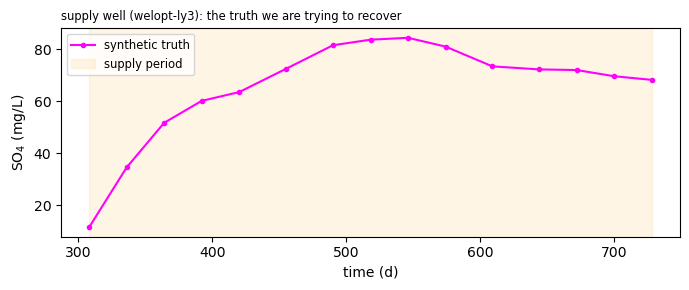

In [9]:
# show the truth's supply-well SO4 breakthrough (central screen welopt-ly3, for display)
fc = conc.loc[(conc.obsid == "welopt-ly3") & (conc.variable == "so4")
              & (conc.time.isin(modeltimes))].sort_values("time")
fc_cols = [c for c in fc.obsnme if c in truth.columns]
fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(fc.set_index("obsnme").loc[fc_cols, "time"].values,
        truth.loc[truth_real, fc_cols].values * 1000.0 * SO4_MW,
        "-o", ms=3, color="fuchsia", label="synthetic truth")
ax.axvspan(308, 728, color="orange", alpha=0.1, label="supply period")
ax.set_xlabel("time (d)")
ax.set_ylabel("SO$_4$ (mg/L)")
ax.set_title("supply well (welopt-ly3): the truth we are trying to recover",
             loc="left", fontsize="small")
ax.legend(fontsize="small")
fig.tight_layout()


Now **drop the truth from the data**. The emulator must never see it: the whole exercise is to recover a withheld reality from history-period data alone. We also hold back a handful of further realisations as a *validation set* — these are realisations the emulator will not train on, so we can check its predictions against the full model's actual outputs (the fidelity check, step 2):


In [10]:
# drop the truth
data = data.drop(index=truth.index)

# hold out a validation set for the fidelity check
rng = np.random.default_rng(0)
val_reals = rng.choice(data.index.values,
                       size=min(20, data.shape[0] // 5),
                       replace=False)
validation = data.loc[val_reals].copy()
train = data.drop(index=val_reals).copy()
print(f"training realisations:   {train.shape[0]}")
print(f"validation realisations: {validation.shape[0]} (held out, never trained on)")
print(f"synthetic truth:         1 (held out)")

training realisations:   174
validation realisations: 20 (held out, never trained on)
synthetic truth:         1 (held out)


## 2. Fidelity check first

Before conditioning on anything, we train DSI and ask the only question that matters for an emulator: **can it reproduce model outputs it has never seen?** We have the perfect test set sitting idle — the validation realisations the prior MC already ran. We feed each one's *true* outputs through the emulator's encode/decode round-trip and compare against the full model's actual values. This costs nothing: no new DIZON runs.


### The naive fit (and why it fails)

DSI works in a transformed observation space. The instinct is to standardise the data (subtract the mean, divide by the standard deviation) and run the SVD on that. Let us do exactly that first — `standard_scaler` — and see what the emulator predicts for the held-out realisations:


In [11]:
transforms = [{"type": "standard_scaler"}]
dsi_naive = DSI(data=train, transforms=transforms, energy_threshold=0.975)
dsi_naive.fit()
print(f"latent dimension (retained components): {dsi_naive.latent_dim}")

latent dimension (retained components): 108


To reconstruct a held-out realisation we project its (transformed) outputs onto the latent space and decode. `predict` takes latent coordinates, so we encode the validation realisations into latent space first, then decode them back:


In [12]:
def encode(dsi, df):
    """Project realisations (obs-space rows) onto DSI latent coordinates.

    Numerical care is load-bearing here. A naive least-squares projection of a
    vector that lies (even slightly) outside the training subspace can return
    latents with enormous norms, and the normal-score back-transform then
    extrapolates them quadratically into absurdity (we saw concentrations of
    1e16 mol/L before adding the two guards below). So:
    1. clip each transformed value into its training range -- outside it the
       normal-score transform is extrapolating, not interpolating;
    2. project with a rank-revealing pseudo-inverse rather than raw lstsq.
    """
    xt = dsi.transformer_pipeline.transform(df.copy())
    xt = xt.loc[:, dsi.ovals.index]
    # guard 1: stay inside the training range of the transformed space
    lo = dsi.data_transformed[dsi.ovals.index].min(axis=0)
    hi = dsi.data_transformed[dsi.ovals.index].max(axis=0)
    xt = xt.clip(lower=lo, upper=hi, axis=1)
    dev = xt.values - dsi.ovals.values[np.newaxis, :]
    # guard 2: stable projection
    pinv = np.linalg.pinv(dsi.pmat, rcond=1e-8)
    pvals = pinv @ dev.T
    return pd.DataFrame(pvals.T, index=df.index,
                        columns=[f"p_{i}" for i in range(dsi.pmat.shape[1])])


# encode + decode the held-out realisations with the naive emulator
val_latent_naive = encode(dsi_naive, validation)
val_pred_naive = dsi_naive.predict(val_latent_naive)

Now the tell-tale failure. Concentrations are physical: they cannot be negative. A standard-scaler fit reconstructs in an unbounded linear space, so the decoded predictions routinely go below zero — especially for the long pre-breakthrough stretches where the true concentration is exactly zero:


In [13]:
neg_frac = (val_pred_naive.values < 0).mean()
min_pred = val_pred_naive.values.min()
print(f"fraction of predicted values that are NEGATIVE: {neg_frac:.1%}")
print(f"most negative predicted concentration (mol/L): {min_pred:.4e}")
print("\nNon-physical. An emulator that invents negative concentrations cannot "
      "be trusted to condition the forecast.")

fraction of predicted values that are NEGATIVE: 9.2%
most negative predicted concentration (mol/L): -1.9391e-04

Non-physical. An emulator that invents negative concentrations cannot be trusted to condition the forecast.


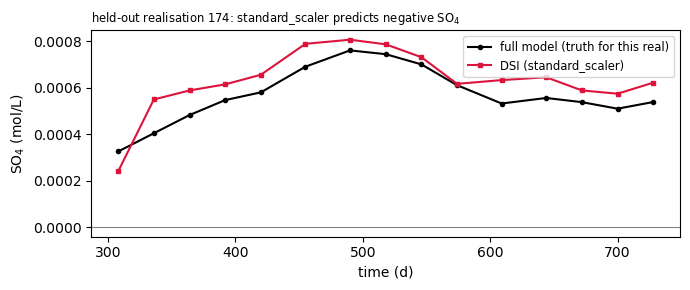

In [14]:
# look at it on one validation realisation's supply-well SO4 breakthrough
vr = validation.index[0]
fig, ax = plt.subplots(figsize=(7, 3))
t = fc.set_index("obsnme").loc[fc_cols, "time"].values
ax.plot(t, validation.loc[vr, fc_cols].values, "-o", ms=3, color="k",
        label="full model (truth for this real)")
ax.plot(t, val_pred_naive.loc[vr, fc_cols].values, "-s", ms=3, color="crimson",
        label="DSI (standard_scaler)")
ax.axhline(0.0, color="grey", lw=0.8)
ax.set_xlabel("time (d)")
ax.set_ylabel("SO$_4$ (mol/L)")
ax.set_title(f"held-out realisation {vr}: standard_scaler predicts negative SO$_4$",
             loc="left", fontsize="small")
ax.legend(fontsize="small")
fig.tight_layout()

### The fix: a normal-score transform

The cure is to give DSI a transformed space where the SVD's Gaussian assumptions hold *and* the back-transform stays inside the physical range. The **normal-score transform** maps each observation's marginal to a standard normal using the empirical distribution from the training ensemble; the inverse maps strictly back within the range the training data spanned. With quadratic tail extrapolation the inverse is exact and monotone, so a reconstructed value cannot fall below the smallest training value for that observation — and for the pre-breakthrough zeros, that floor is zero.

(`log10` is the other common choice for concentrations, and the vendored transformer handles zeros via a learned shift. We prefer `normal_score` here because the breakthrough series mixes hard zeros with a skewed positive tail, which the empirical normal score handles without a single global shift.)


In [15]:
transforms = [{"type": "normal_score", "quadratic_extrapolation": True}]
dsi = DSI(data=train, transforms=transforms, energy_threshold=0.975)
dsi.fit()
# energy_threshold matters: at 0.999 the latent space keeps ~170 components for
# ~190 training realisations -- nearly full rank, so conditioning can "fit" the
# history by composing noise-level components that carry no real information
# about the forecast (we learned this the hard way: the posterior detached from
# the truth entirely). 0.975 keeps the dominant, genuinely-correlated structure.
print(f"latent dimension (retained components): {dsi.latent_dim}")

latent dimension (retained components): 116


In [16]:
val_latent = encode(dsi, validation)
val_pred = dsi.predict(val_latent)

neg_frac = (val_pred.values < -1e-9).mean()
print(f"fraction of predicted values that are meaningfully NEGATIVE: {neg_frac:.2%}")
print(f"most negative predicted concentration (mol/L): {val_pred.values.min():.2e}")

# the fidelity check is not just a plot -- it is a MEASUREMENT of the
# emulator's error, per observation, on realisations it never saw. We keep it:
# this error joins the noise budget when we condition below.
emu_rmse = ((val_pred[validation.columns] - validation) ** 2).mean(axis=0) ** 0.5
print(f"emulator per-obs RMSE: median {emu_rmse.median():.3g}, "
      f"max {emu_rmse.max():.3g} (model units)")

fraction of predicted values that are meaningfully NEGATIVE: 0.27%
most negative predicted concentration (mol/L): -3.07e-04
emulator per-obs RMSE: median 5.58e-05, max 0.497 (model units)


Essentially no negatives — the handful that remain are tiny tail-extrapolation artefacts at the floor, orders of magnitude smaller than the -27 mol/L excursions the standard-scaler produced, and they vanish if we clip at zero. Now the real fidelity test: does the emulator reproduce the **forecast** for realisations it never saw? We compare DSI's predicted peak SO₄ against the full model's actual peak SO₄ across the validation set. Points on the 1:1 line mean the emulator is faithful where it counts:


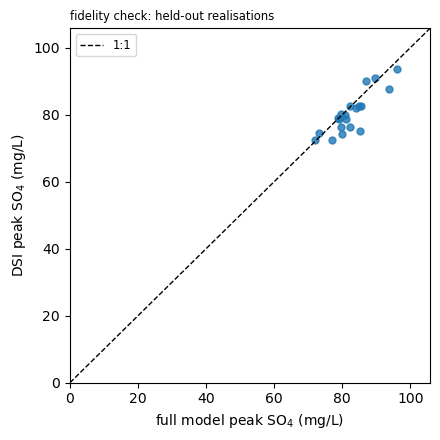

In [17]:
true_peak = peak_so4_mgl(validation)
pred_peak = peak_so4_mgl(val_pred)
common = true_peak.index.intersection(pred_peak.index)

fig, ax = plt.subplots(figsize=(4.5, 4.5))
lim = [0, max(true_peak.max(), pred_peak.max()) * 1.1]
ax.plot(lim, lim, "k--", lw=1, label="1:1")
ax.scatter(true_peak.loc[common], pred_peak.loc[common], s=25,
           color="#1f77b4", alpha=0.8)
ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel("full model peak SO$_4$ (mg/L)")
ax.set_ylabel("DSI peak SO$_4$ (mg/L)")
ax.set_title("fidelity check: held-out realisations", loc="left", fontsize="small")
ax.legend(fontsize="small")
fig.tight_layout()

The series principle, restated now that we have seen both halves of it: **never trust an emulator you have not tested.** The naive fit looked plausible until we asked it for a held-out prediction; the normal-score fit earns the right to be conditioned. With the fidelity check passed, we proceed.


## 3. Condition the emulator with PESTPP-IES

Conditioning the emulator means running PESTPP-IES against it instead of against DIZON. `DSI.prepare_pestpp` writes a complete PEST++ interface into a template directory: a control file (`dsi.pst`), a pickled emulator (`dsi.pickle`), and a forward-run script. The DSI "parameters" are the latent coordinates; the "observations" are the obs-space outputs the emulator predicts.


### Why `use_runstor=True`

There are two ways the emulator's forward run can talk to PEST++. The file-based path writes a CSV of latent coordinates, runs the emulator once, and reads a CSV of outputs — one process launch per realisation. For an emulator that is cheap per call but called thousands of times, that launch overhead dominates. The **runstor** path instead lets PESTPP-IES write all the realisations' parameters into a single run-storage file (`dsi.rns`), runs the emulator once over the whole batch, and writes every realisation's outputs back into the same file. It is invoked with the `/e` flag (`pestpp-ies dsi.pst /e`), which is what tells PEST++ to use run storage.


In [18]:
dtd = Path("dsi_template")
dpst = dsi.prepare_pestpp(dtd, use_runstor=True)
print(f"DSI template written to {dtd}")
print(f"latent parameters: {dpst.npar}, emulated observations: {dpst.nobs}")

noptmax:0, npar_adj:116, nnz_obs:0
DSI template written to dsi_template
latent parameters: 116, emulated observations: 1795


`prepare_pestpp` generates a single, self-contained `forward_run.py` for us (no hand-editing, no drift). Because we asked for `use_runstor=True`, its `__main__` calls `dsi_runstore_forward_run`, which loads `dsi.pickle`, reads the latent coordinates from the `.rns`, predicts the whole batch in one call, and writes the outputs back. Let us confirm the generated script is wired the way we expect:


In [19]:
frun = (dtd / "forward_run.py").read_text()
assert "dsi_runstore_forward_run" in frun, \
    "forward_run.py is not runstor-wired; re-run prepare_pestpp(use_runstor=True)"
# show the __main__ entry point
print(frun.splitlines()[-2])
print(frun.splitlines()[-1])

if __name__ == "__main__":
    dsi_runstore_forward_run()


### Set the targets, weights and noise

The control file comes out with the truth as obsvals and zero weights. We set the **synthetic truth** as the conditioning targets, then apply weights only to the history-period observations (day ≤ 252) of the conditioning species — nothing after the decision date informs the history match, and the held-back cations stay at zero weight (we cash those in later, in the dataworth notebook).


In [20]:
dobs = dpst.observation_data
dobs["time"] = pd.to_numeric(dobs["time"], errors="coerce")

# the synthetic truth becomes the conditioning target
dobs.loc[truth.columns, "obsval"] = truth.values[0]
dobs["weight"] = 0.0

# conditioning species (held-back cations excluded); pe never conditioned on
cond_species = ["so4", "o0", "no3", "ph", "tmp"]  # o0 = dissolved O2 in this model
is_cond = dobs.variable.isin(cond_species)
is_history = dobs.time <= 252
nz = dobs.loc[is_cond & is_history & (dobs.obsval < 1e30)].index

Noise is **species-specific** and follows the table set in part1_03: a proportional standard deviation with a floor for concentrations, and an absolute standard deviation for pH (~0.1) and temperature (~0.5 °C). The weight is the inverse of the standard deviation:


In [21]:
# species-specific measurement noise (the canonical table from part1_03)
CONC_PROP = 0.07          # 7% proportional for concentration species
CONC_FLOOR_MOLL = {       # per-species absolute floor on the conc sigma (mol/L)
    "so4": 5.0e-5,
    "o0":  2.0e-5,
    "no3": 2.0e-5,
}
PH_ABS = 0.1              # absolute, pH units
TMP_ABS = 0.5 * 1e-3      # absolute, 0.5 degrees C -- in STORED units (Tmp is carried x1e-3)

std = pd.Series(0.0, index=nz)
var = dobs.loc[nz, "variable"]
val = dobs.loc[nz, "obsval"].astype(float)
is_ph = var == "ph"
is_tmp = var == "tmp"
is_conc = ~(is_ph | is_tmp)
floor = var[is_conc].map(CONC_FLOOR_MOLL).fillna(0.0).astype(float)
std[is_conc] = np.maximum(val[is_conc].abs() * CONC_PROP, floor)
std[is_ph] = PH_ABS
std[is_tmp] = TMP_ABS

# the emulator is not the model: its error must enter the noise budget, or the
# ensemble smoother treats ~1,800 highly redundant observations as exact
# information and collapses the posterior far tighter than the data justify --
# tightly enough to exclude the truth (we tried; it does). The fidelity check
# already MEASURED that error per obs on held-out realisations, so we combine
# the two sources the standard way:
sigma_emu = emu_rmse.reindex(nz).fillna(0.0)
std_total = np.sqrt(std ** 2 + sigma_emu ** 2)

# one more consistency requirement, easy to miss: our noise model (below) says
# measurement error is CORRELATED within each site:species series -- more like
# a bias on the instrument than independent scatter. The weights must say the
# same thing, or the smoother counts ~20 samples of one biased series as ~20
# independent facts. PEST++ cannot take a full error covariance, so we use the
# standard workaround: deflate each series' weights by sqrt(n) so the whole
# series carries roughly one series' worth of information.
series = dobs.loc[nz, "obsid"].astype(str) + ":" + dobs.loc[nz, "variable"].astype(str)
n_per_series = series.map(series.value_counts())
std_total = std_total * np.sqrt(n_per_series.astype(float))

dobs.loc[nz, "standard_deviation"] = std_total
dobs.loc[nz, "weight"] = 1.0 / std_total
infl = (std_total / std).replace([np.inf], np.nan)
print(f"{len(nz)} history-period conditioning obs weighted; "
      f"emulator error inflates sigma by x{infl.median():.1f} (median), "
      f"x{infl.quantile(0.95):.1f} (P95)")

1750 history-period conditioning obs weighted; emulator error inflates sigma by x5.2 (median), x11.4 (P95)


Group the observations per site:species so PEST++ can balance phi across them (no single well-species pair dominates the objective), and split the phi budget evenly across groups:


In [22]:
# NOTE: an earlier draft balanced the conditioning with a per-group phi-factor
# file (ies_phi_factor_file). We dropped it, deliberately: phi factors tell
# PESTPP-IES to rescale each group's weights to a fixed share of the objective
# function -- which silently OVERRIDES the noise budget we just built (the
# absolute sigmas stop mattering; only their ratios within a group survive).
# Balancing-by-construction through the species sigma table, with the
# emulator error folded in, is the weighting philosophy of this notebook;
# phi factors belong to messier weighting problems (see part1_03's discussion
# of field data, where sampling density varies wildly between series).
dobs["obgnme"] = dobs.obsid.astype(str) + ":" + dobs.variable.astype(str)
dpst.pestpp_options.pop("ies_phi_factor_file", None)
print(f"{dobs.loc[nz,'obgnme'].nunique()} site:species obs groups; "
      "weights carry the noise budget directly (no phi-factor rebalance)")

106 site:species obs groups; weights carry the noise budget directly (no phi-factor rebalance)


Build the **observation noise ensemble**. Each realisation of the targets is the truth plus a draw from the species-specific noise; zero-valued (pre-breakthrough) observations stay exactly zero so we do not invent negative measurements:


In [23]:
n_reals = 500
dpst.pestpp_options["ies_num_reals"] = n_reals
dpst.pestpp_options["save_binary"] = True

noise = pyemu.ObservationEnsemble.from_gaussian_draw(dpst, num_reals=n_reals)

# overwrite the weighted columns with truth + noise. The noise is drawn
# CORRELATED within each site:species series (one standard-normal draw per
# realisation per group, scaled by each obs's own sigma): measurement error on
# a single instrument's time series behaves more like a bias than independent
# scatter, and independent noise on ~1,800 redundant obs would overstate the
# information content.
nzobs = dobs.loc[nz].copy()
rng = np.random.default_rng(20260605)
for grp in nzobs.obgnme.unique():
    g = nzobs.loc[nzobs.obgnme == grp]
    z = rng.standard_normal(noise.shape[0])
    noise.loc[:, g.index] = (g.obsval.values[None, :]
                             + z[:, None] * g.standard_deviation.values[None, :])

# pre-breakthrough zeros stay zero
zero_obs = nzobs.loc[nzobs.obsval == 0].index
noise.loc[:, zero_obs] = 0.0
noise._df = noise._df.dropna(axis=1)
noise.to_binary(str(dtd / "noise.jcb"))

'dsi_template/noise.jcb'

### A solver option we deliberately do *not* use

An earlier draft of this curriculum set `ies_multimodal_alpha = 0.99` here — per-realisation solves, intended (in full-model PESTPP-IES work) to protect against outlier realisations and prior-data conflict. We tested it on this emulator-space problem against two controls, and the evidence ran the other way: with the multimodal solve the posterior tightened well past what the data can justify and shifted away from the truth; without it, the posterior closely matched a nearest-neighbour reference built directly from the training ensemble. Per-realisation solves earn their keep when individual realisations can genuinely fail or conflict — neither happens inside a linear emulator. So: default solver, deliberately.

In [24]:
# default IES solver -- no multimodal options (see the cell above for why)
dpst.pestpp_options.pop("ies_multimodal_alpha", None)
dpst.pestpp_options["ies_num_threads"] = psutil.cpu_count(logical=False)
dpst.control_data.noptmax = 3
dpst.write(str(dtd / "dsi.pst"), version=2)

noptmax:3, npar_adj:116, nnz_obs:1750


### Run it (cheap — this is live)

Copy the platform binaries in and run PESTPP-IES against the emulator in run-storage mode (`/e`). Unlike every other run in this curriculum, this one is genuinely cheap: there is no DIZON in the loop, only the emulator. Three iterations over a 500-member ensemble finish in seconds to a couple of minutes, so we run it live rather than loading a prebaked result.


In [25]:
hbd.get_bins(str(dtd))
pyemu.os_utils.run("pestpp-ies dsi.pst /e", cwd=str(dtd))

./pestpp-ies dsi.pst /e




             pestpp-ies: a GLM iterative ensemble smoother

                   by the PEST++ development team

...processing command line: ' ./pestpp-ies dsi.pst /e'
...using external run manager


version: 5.2.24
binary compiled on Nov 12 2025 at 11:54:09

using control file: "dsi.pst"
in directory: "/Users/ruihugman/GitHub/rtm-tutorial/tutorials/part1_05_dsi_basics/dsi_template"
on host: "Ruis-MacBook-Pro.local"
on a(n) apple operating system
with release configuration
started at 06/06/26 07:35:41

processing control file dsi.pst
              starting external run manager ...


  ---  initializing  ---  
...using glm algorithm
...using REDSVD for truncated svd solve
...maxsing: 10000000
...eigthresh:  1e-06
...initializing localizer
...not using localization
...using lambda multipliers: 0.1 , 1 , 10 , 
...using lambda scaling factors: 0.75 , 1 , 1.1 , 
...acceptable phi factor:  1.05
...lambda increase factor:  10
...lambda decrease factor:  0.75
...max run fail:  1
...initializin

...saved weight ensemble to  dsi.weights.jcb
...adding 'base' parameter values to ensemble
...adding 'base' observation values to ensemble
...adding 'base' weight values to weight ensemble
...saved initial parameter ensemble to  dsi.0.par.jcb
...saved obs+noise observation ensemble (obsval + noise realizations) to  dsi.obs+noise.jcb
...using subset in lambda testing, percentage of realizations used in subset testing:  10
...subset how:  RANDOM
...centering on ensemble mean vector
...running initial ensemble of size 500
06/06/26 07:35:41 external run manager calling forward run command(s)
06/06/26 07:35:41 calling forward run command: 'python forward_run.py' 
...pid: 64181


...exit_code: 64181
...status: 0
06/06/26 07:35:43 forward run command(s) finished, took 1.805 seconds
...saved initial obs ensemble to dsi.0.obs.jcb
saved par and rei files for realization BASE for iteration 0
saved par and rei files for realization BASE

  ---  pre-drop initial phi summary  ---  
       phi type           mean            std            min            max
       measured        2492.13        345.056        339.622        5232.46
         actual        744.445        319.884        292.268        3487.83
     note: 'measured' phi reported above includes 
           realizations of measurement noise, 
           'actual' phi does not.


  ---  observation group phi summary ---  
       (computed using 'actual' phi)
           (sorted by mean phi)
group        count  nconflict      mean       std       min       max   percent       std
wp2-f4:o0       18          0      49.2      27.6     0.225      86.3      6.93      4.03
wp2-f2:o0       17          0      33.4      20.5     0.215      64.1      4.71         3
wp3-f2:o0       17          0      23.3      17.2    0.0774      47.9      3.25      2.48
wp2-f4:no3      17          0      22.8      13.7     0.594      66.7      3.18      1.65
wp3-f4:o0       18          0      21.1      16.8    0.0982      47.9      2.94       2.4
ip2-f5:o0       18          0      20.6        17     0.109      79.4      2.93      2.49
wp2-f4:tmp      18          0      19.6        21     0.264      89.4      2.52      2.49
wp3-f3:tmp      18          0      15.9      10.4     0.367      39.3      2.26      1.53
ip2-f1:so4      18          0      15.4      19.6  7.71e-05       124         

...

...finished calcs for: 0.005625

  ---  running upgrade ensembles  ---  
...subset idx:pe real name:  1:222, 3:BASE, 9:82, 24:301, 53:45, 59:107, 72:251, 92:437, 97:1, 98:2, 99:3, 109:16, 111:18, 112:19, 135:44, 143:54, 149:61, 156:71, 159:74, 160:75, 176:97, 189:115, 193:119, 223:157, 224:158, 227:161, 268:206, 272:210, 274:212, 292:233, 295:236, 305:248, 315:260, 324:269, 326:272, 336:285, 337:287, 368:326, 376:336, 378:339, 387:351, 393:361, 396:366, 420:396, 439:420, 441:422, 464:451, 471:463, 491:489, 498:497, 
...subset idx:oe real name:  1:222, 3:BASE, 9:82, 24:301, 53:45, 59:107, 72:251, 92:437, 97:1, 98:2, 99:3, 109:16, 111:18, 112:19, 135:44, 143:54, 149:61, 156:71, 159:74, 160:75, 176:97, 189:115, 193:119, 223:157, 224:158, 227:161, 268:206, 272:210, 274:212, 292:233, 295:236, 305:248, 315:260, 324:269, 326:272, 336:285, 337:287, 368:326, 376:336, 378:339, 387:351, 393:361, 396:366, 420:396, 439:420, 441:422, 464:451, 471:463, 491:489, 498:497, 
06/06/26 07:35:58 external ru

...exit_code: 64193
...status: 0
06/06/26 07:36:00 forward run command(s) finished, took 1.503 seconds

  ---  evaluating upgrade ensembles  ---  
...last mean:  1743.02
...last stdev:  98.4084



  ---  phi summary for best lambda, scale fac: 5.625e-05 , 1.1 ,   ---  
       phi type           mean            std            min            max
       measured        1681.15        243.573        32.8633        1863.65
         actual        85.8393        14.4605        32.8633        122.393
     note: 'measured' phi reported above includes 
           realizations of measurement noise, 
           'actual' phi does not.

  ---  running remaining realizations for best lambda, scale:5.625e-05 , 1.1 ,   ---  
06/06/26 07:36:00 external run manager calling forward run command(s)
06/06/26 07:36:00 calling forward run command: 'python forward_run.py' 
...pid: 64195


...exit_code: 64195
...status: 0
06/06/26 07:36:02 forward run command(s) finished, took 1.524 seconds
...phi summary for entire ensemble using lambda,scale_fac 5.625e-05 , 1.1 , 
       phi type           mean            std            min            max
       measured        1723.54         97.847        32.8633        1917.22
         actual        85.9895          12.24        32.8633        135.834
     note: 'measured' phi reported above includes 
           realizations of measurement noise, 
           'actual' phi does not.
...last best mean phi * acceptable phi factor:  1830.17
...current best mean phi:  1723.54

  ---  updating parameter ensemble  ---  

  ---  updating lambda to  4.21875e-05  ---  

  ---  EnsembleMethod iteration 3 report  ---  
   number of active realizations:   500
   number of model runs:            0
      current obs ensemble saved to dsi.3.obs.jcb
      current par ensemble saved to dsi.3.par.jcb
saved par and rei files for realization BASE for ite

saved par and rei files for realization BASE
       phi type           mean            std            min            max
       measured        1723.54         97.847        32.8633        1917.22
         actual        85.9895          12.24        32.8633        135.834
     note: 'measured' phi reported above includes 
           realizations of measurement noise, 
           'actual' phi does not.
  ---  observation group phi summary ---  
       (computed using 'actual' phi)
           (sorted by mean phi)
group        count  nconflict      mean       std       min       max   percent       std
wp2-f4:no3      17          0      8.89      2.31      3.14      21.3      10.5      2.83
wp2-f4:ph       18          0      3.96     0.472      1.47      5.93       4.7     0.881
wp2-f4:so4      18          0      2.58      2.38     0.872      23.5      2.96      2.37
wp4-f5:no3      14          0      2.42      1.59     0.214      12.6      2.81      1.74
wp3-f3:no3      17          0    

## 4. The payoff: the posterior forecast distribution (and the compute bill)

Load the conditioned ensemble. Iteration 0 is the prior (the emulator's unconditioned spread), and the last iteration is the DSI posterior — the forecast distribution after conditioning on the history-period data. We read the payoff as the **change in the forecast distribution** from prior to posterior: its median and its P95 (the quantile the operator designs treatment capacity to), and where the truth sits relative to both.


In [26]:
rpst = pyemu.Pst(str(dtd / "dsi.pst"))
obsen = rpst.ies.obsen
# iterations available on disk (0 = prior, max = posterior)
iters = sorted(obsen.index.get_level_values(0).unique()) \
    if isinstance(obsen.index, pd.MultiIndex) else None
oe_prior = obsen.loc[0].copy()
last_it = max(i for i in [0, 1, 2, 3] if (dtd / f"dsi.{i}.obs.jcb").exists())
oe_post = obsen.loc[last_it].copy()
print(f"prior: {oe_prior.shape[0]} reals | posterior (iter {last_it}): "
      f"{oe_post.shape[0]} reals")

dsi.obs.
prior: 500 reals | posterior (iter 3): 500 reals


In [27]:
# forecast under prior and posterior (emulated), plus the truth
prior_fc = peak_so4_mgl(oe_prior)
post_fc = peak_so4_mgl(oe_post)
truth_fc = float(peak_so4_mgl(truth).iloc[0])

# the payoff: the prior -> posterior shift in the forecast distribution
print(f"synthetic truth peak SO4: {truth_fc:.1f} mg/L")
print(f"prior     peak SO4 (mg/L): median={prior_fc.median():.0f}  "
      f"P5={prior_fc.quantile(0.05):.0f}  P95={prior_fc.quantile(0.95):.0f}")
print(f"posterior peak SO4 (mg/L): median={post_fc.median():.0f}  "
      f"P5={post_fc.quantile(0.05):.0f}  P95={post_fc.quantile(0.95):.0f}")

shift = post_fc.median() - prior_fc.median()
tighten = (post_fc.quantile(0.95) - post_fc.quantile(0.05)) - \
          (prior_fc.quantile(0.95) - prior_fc.quantile(0.05))
direction = "up" if shift > 0 else "down"
print(f"\nconditioning moved the forecast median {prior_fc.median():.0f} -> "
      f"{post_fc.median():.0f} mg/L ({direction}) and the 5-95 band "
      f"{'tightened' if tighten < 0 else 'widened'} by {abs(tighten):.0f} mg/L")
covered = post_fc.quantile(0.05) <= truth_fc <= post_fc.quantile(0.95)
print(f"truth ({truth_fc:.1f} mg/L) {'inside' if covered else 'outside'} the posterior 5-95 band")
print("one truth is one draw: a truth picked in the prior's upper tail can land in the"
      "\nposterior's tail legitimately. Whether the posterior is honestly sized is a"
      "\nCOVERAGE question -- we test it properly below.")

synthetic truth peak SO4: 90.8 mg/L
prior     peak SO4 (mg/L): median=81  P5=71  P95=93
posterior peak SO4 (mg/L): median=78  P5=68  P95=87

conditioning moved the forecast median 81 -> 78 mg/L (down) and the 5-95 band tightened by 3 mg/L
truth (90.8 mg/L) outside the posterior 5-95 band
one truth is one draw: a truth picked in the prior's upper tail can land in the
posterior's tail legitimately. Whether the posterior is honestly sized is a
COVERAGE question -- we test it properly below.


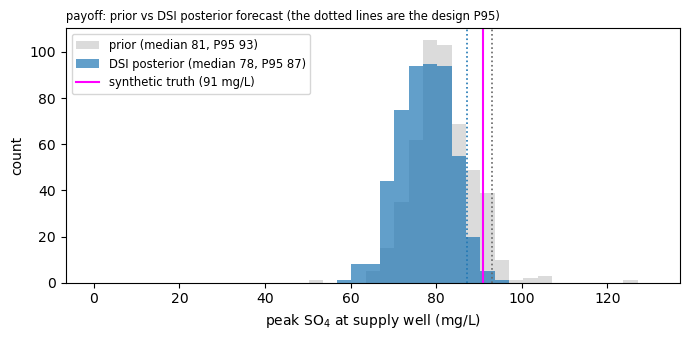

In [28]:
# the payoff figure: prior vs posterior forecast distribution, with the design P95
# of each and where the truth sits. conditioning moves the mass UP and tightens it.
fig, ax = plt.subplots(figsize=(7, 3.5))
fc_max = max(prior_fc.max(), post_fc.max())
bins = np.linspace(0, fc_max * 1.05, 40)
ax.hist(prior_fc, bins=bins, color="#D3D3D3", alpha=0.8,
        label=f"prior (median {prior_fc.median():.0f}, P95 {prior_fc.quantile(0.95):.0f})")
ax.hist(post_fc, bins=bins, color="#1f77b4", alpha=0.7,
        label=f"DSI posterior (median {post_fc.median():.0f}, P95 {post_fc.quantile(0.95):.0f})")
ax.axvline(prior_fc.quantile(0.95), color="0.4", lw=1.2, ls=":")
ax.axvline(post_fc.quantile(0.95), color="#1f77b4", lw=1.2, ls=":")
ax.axvline(truth_fc, color="fuchsia", lw=1.5, label=f"synthetic truth ({truth_fc:.0f} mg/L)")
ax.set_xlabel("peak SO$_4$ at supply well (mg/L)")
ax.set_ylabel("count")
ax.set_title("payoff: prior vs DSI posterior forecast (the dotted lines are the design P95)",
             loc="left", fontsize="small")
ax.legend(fontsize="small")
fig.tight_layout()


A risk statement is a lens on this same distribution, not a different analysis. Suppose your supply contract carried a **90 mg/L trigger** — a clause that costs you above that level. Reading the exceedance probability straight off the prior and posterior forecasts:


In [29]:
# one illustrative risk lens on the same distribution: a 90 mg/L contract trigger
TRIGGER_MGL = 90.0
p_prior = (prior_fc > TRIGGER_MGL).mean()
p_post = (post_fc > TRIGGER_MGL).mean()
print(f"P(peak SO4 > {TRIGGER_MGL:.0f} mg/L) prior     : {p_prior:.2f}")
print(f"P(peak SO4 > {TRIGGER_MGL:.0f} mg/L) posterior : {p_post:.2f}")
moved = "rose" if p_post > p_prior else ("fell" if p_post < p_prior else "did not move")
print(f"the contract risk {moved} with conditioning -- the same shift the "
      "distribution already showed, read through a threshold.")


P(peak SO4 > 90 mg/L) prior     : 0.11
P(peak SO4 > 90 mg/L) posterior : 0.01
the contract risk fell with conditioning -- the same shift the distribution already showed, read through a threshold.


## Is the posterior honestly sized? A calibration check

A single synthetic truth cannot tell you whether your posterior uncertainty is honest — a 5–95% band is *supposed* to miss one truth in ten. But the emulator makes the proper test nearly free: condition on several held-out realisations as if each were the truth, and count how often the posterior band covers the realisation's actual peak. Systematic misses mean the noise budget is still too confident; systematic over-coverage means it is too timid. This habit — *calibrate your posterior like you would calibrate an instrument* — is cheap insurance the full model could never afford:

In [30]:
import shutil as _sh

CAL_TRUTHS = list(validation.index[:6])   # held-out reals the emulator never saw
cal = []
for tr in CAL_TRUTHS:
    wd = Path(f"calib_{tr}")
    if wd.exists():
        _sh.rmtree(wd)
    _sh.copytree(dtd, wd)
    # a used runstor template must be cleaned before re-running
    for patt in ("dsi.rns", "dsi.rec", "frun.out", "dsi.obs+noise.jcb"):
        (wd / patt).unlink(missing_ok=True)
    for f in list(wd.glob("dsi.[0-9].*")) + list(wd.glob("dsi.phi.*")):
        f.unlink()

    cpst = pyemu.Pst(str(wd / "dsi.pst"))
    cobs = cpst.observation_data
    # this realisation's values become the conditioning target
    cobs.loc[nz, "obsval"] = validation.loc[tr, nz].values
    # noise: same budget, recentred, correlated within each series
    cnoise = pyemu.ObservationEnsemble.from_gaussian_draw(cpst, num_reals=n_reals)
    grp_obs = cobs.loc[nz]
    for grp in grp_obs.obgnme.unique():
        g = grp_obs.loc[grp_obs.obgnme == grp]
        z = rng.standard_normal(cnoise.shape[0])
        cnoise.loc[:, g.index] = (g.obsval.values[None, :]
                                  + z[:, None] * g.standard_deviation.values[None, :])
    cnoise._df = cnoise._df.dropna(axis=1)
    cnoise.to_binary(str(wd / "noise.jcb"))
    cpst.write(str(wd / "dsi.pst"), version=2)

    pyemu.os_utils.run("pestpp-ies dsi.pst /e", cwd=str(wd))

    rp = pyemu.Pst(str(wd / "dsi.pst"))
    pen = rp.ies.obsen
    last = max(int(f.name.split(".")[1]) for f in wd.glob("dsi.[0-9].obs.jcb"))
    pk = peak_so4_mgl(pen.loc[last])
    actual = float(true_peak.loc[tr])
    lo, hi = pk.quantile(0.05), pk.quantile(0.95)
    cal.append((tr, actual, lo, hi, lo <= actual <= hi))
    print(f"truth {tr}: actual {actual:5.1f}  posterior 5-95 [{lo:5.1f}, {hi:5.1f}]"
          f"  {'covered' if cal[-1][-1] else 'missed'}")
    _sh.rmtree(wd)

n_cov = sum(c[-1] for c in cal)
print(f"\ncoverage: the posterior 5-95 band covered {n_cov} of {len(cal)} held-out "
      "truths (an honestly-sized band should cover roughly 9 in 10)")

noptmax:3, npar_adj:116, nnz_obs:1750
./pestpp-ies dsi.pst /e




             pestpp-ies: a GLM iterative ensemble smoother

                   by the PEST++ development team

...processing command line: ' ./pestpp-ies dsi.pst /e'
...using external run manager


version: 5.2.24
binary compiled on Nov 12 2025 at 11:54:09

using control file: "dsi.pst"
in directory: "/Users/ruihugman/GitHub/rtm-tutorial/tutorials/part1_05_dsi_basics/calib_174"
on host: "Ruis-MacBook-Pro.local"
on a(n) apple operating system
with release configuration
started at 06/06/26 07:36:02

processing control file dsi.pst
              starting external run manager ...


  ---  initializing  ---  
...using glm algorithm
...using REDSVD for truncated svd solve
...maxsing: 10000000
...eigthresh:  1e-06
...initializing localizer
...not using localization
...using lambda multipliers: 0.1 , 1 , 10 , 
...using lambda scaling factors: 0.75 , 1 , 1.1 , 
...acceptable phi factor:  1.05
...lambda increase factor:  10
...lambda decrease factor:  0.75
...max run fail:  1
...initializing p

...saved weight ensemble to  dsi.weights.jcb
...adding 'base' parameter values to ensemble
...adding 'base' observation values to ensemble
...adding 'base' weight values to weight ensemble
...saved initial parameter ensemble to  dsi.0.par.jcb
...saved obs+noise observation ensemble (obsval + noise realizations) to  dsi.obs+noise.jcb
...using subset in lambda testing, percentage of realizations used in subset testing:  10
...subset how:  RANDOM
...centering on ensemble mean vector
...running initial ensemble of size 500
06/06/26 07:36:03 external run manager calling forward run command(s)
06/06/26 07:36:03 calling forward run command: 'python forward_run.py' 
...pid: 64198


...exit_code: 64198
...status: 0
06/06/26 07:36:05 forward run command(s) finished, took 1.878 seconds
...saved initial obs ensemble to dsi.0.obs.jcb
saved par and rei files for realization BASE for iteration 0
saved par and rei files for realization BASE

  ---  pre-drop initial phi summary  ---  
       phi type           mean            std            min            max
       measured        2498.38        384.844        371.592        5485.75
         actual        751.925        364.598        240.581        3901.31
     note: 'measured' phi reported above includes 
           realizations of measurement noise, 
           'actual' phi does not.


  ---  observation group phi summary ---  
       (computed using 'actual' phi)
           (sorted by mean phi)
group        count  nconflict      mean       std       min       max   percent       std
ip2-f5:o0       18          0      37.5      33.8    0.0698       138      5.14      4.75
wp2-f2:tmp      18          0      30.3      18.7     0.645       297      4.26      2.25
wp2-f2:no3      17          0      28.3      9.72      1.49      53.9      4.13      1.64
wp2-f2:so4      18          0      19.7        14      2.38       234      2.77      1.69
wp2-f2:o0       17          0      17.8      17.9     9e-05      82.1      2.39      2.28
wp2-f5:tmp      18          0      16.9      12.6     0.112      43.4      2.22      1.52
wp1-f2:so4      18          0      16.8      14.8    0.0467        70      2.33      1.98
wp2-f3:o0       17          0      16.8      13.6     0.321      40.1      2.39      2.03
wp2-f5:so4      18          0      16.8      10.4      1.54      52.9      2.2

...

...finished calcs for: 0.005625

  ---  running upgrade ensembles  ---  
...subset idx:pe real name:  1:222, 3:BASE, 9:82, 24:301, 53:45, 59:107, 72:251, 92:437, 97:1, 98:2, 99:3, 109:16, 111:18, 112:19, 135:44, 143:54, 149:61, 156:71, 159:74, 160:75, 176:97, 189:115, 193:119, 223:157, 224:158, 227:161, 268:206, 272:210, 274:212, 292:233, 295:236, 305:248, 315:260, 324:269, 326:272, 336:285, 337:287, 368:326, 376:336, 378:339, 387:351, 393:361, 396:366, 420:396, 439:420, 441:422, 464:451, 471:463, 491:489, 498:497, 
...subset idx:oe real name:  1:222, 3:BASE, 9:82, 24:301, 53:45, 59:107, 72:251, 92:437, 97:1, 98:2, 99:3, 109:16, 111:18, 112:19, 135:44, 143:54, 149:61, 156:71, 159:74, 160:75, 176:97, 189:115, 193:119, 223:157, 224:158, 227:161, 268:206, 272:210, 274:212, 292:233, 295:236, 305:248, 315:260, 324:269, 326:272, 336:285, 337:287, 368:326, 376:336, 378:339, 387:351, 393:361, 396:366, 420:396, 439:420, 441:422, 464:451, 471:463, 491:489, 498:497, 
06/06/26 07:38:10 external ru

...exit_code: 64369
...status: 0
06/06/26 07:38:12 forward run command(s) finished, took 1.516 seconds

  ---  evaluating upgrade ensembles  ---  
...last mean:  1727.23
...last stdev:  98.6275



  ---  phi summary for best lambda, scale fac: 5.625e-05 , 1.1 ,   ---  
       phi type           mean            std            min            max
       measured        1667.09        243.577        19.1597        1835.18
         actual        78.1503        15.8878        19.1597        123.296
     note: 'measured' phi reported above includes 
           realizations of measurement noise, 
           'actual' phi does not.

  ---  running remaining realizations for best lambda, scale:5.625e-05 , 1.1 ,   ---  
06/06/26 07:38:12 external run manager calling forward run command(s)
06/06/26 07:38:12 calling forward run command: 'python forward_run.py' 
...pid: 64370


...exit_code: 64370
...status: 0
06/06/26 07:38:13 forward run command(s) finished, took 1.546 seconds
...phi summary for entire ensemble using lambda,scale_fac 5.625e-05 , 1.1 , 
       phi type           mean            std            min            max
       measured        1708.92        98.0365        19.1597        1908.96
         actual        77.4756         12.127        19.1597        142.558
     note: 'measured' phi reported above includes 
           realizations of measurement noise, 
           'actual' phi does not.
...last best mean phi * acceptable phi factor:  1813.59
...current best mean phi:  1708.92

  ---  updating parameter ensemble  ---  

  ---  updating lambda to  4.21875e-05  ---  

  ---  EnsembleMethod iteration 3 report  ---  
   number of active realizations:   500
   number of model runs:            0
      current obs ensemble saved to dsi.3.obs.jcb
      current par ensemble saved to dsi.3.par.jcb


saved par and rei files for realization BASE for iteration 3
saved par and rei files for realization BASE
       phi type           mean            std            min            max
       measured        1708.92        98.0365        19.1597        1908.96
         actual        77.4756         12.127        19.1597        142.558
     note: 'measured' phi reported above includes 
           realizations of measurement noise, 
           'actual' phi does not.
  ---  observation group phi summary ---  
       (computed using 'actual' phi)
           (sorted by mean phi)
group        count  nconflict      mean       std       min       max   percent       std
wp3-f3:no3      17          0      2.79      1.81     0.212      13.8       3.6       2.2
wp1-f4:no3      13          0      2.74      2.93    0.0703      19.5      3.49       3.5
wp1-f4:tmp      18          0      2.25      1.13     0.145      5.79      2.93      1.47
wp3-f1:no3      15          0      1.76      1.29    0.0265   

If coverage comes back systematically low, the remedy is more humility in the noise budget (a larger emulator-error allowance, or stronger weight deflation) — *not* a different truth. The forecast distribution is only worth carrying into decisions if its stated confidence survives this kind of audit.

(The EU drinking-water standard for sulfate is 250 mg/L; the supplied water is comfortably below it under both prior and posterior, so cost, not compliance, drives this decision.)


And the contrast that is the whole point of this curriculum. Conditioning the forecast the conventional way — PESTPP-IES against DIZON, three iterations of a few hundred ~6 min runs — is **days** of compute. Conditioning the *emulator*, to the same forecast question, took the run you just watched: **seconds to minutes**, after the one-time prior MC that we had already paid for. We sharpened the forecast — moved its median and its design P95 — for almost nothing on top of the prior Monte Carlo, which was the only expensive ingredient. In the notebooks that follow, DSI lets us re-use that same investment to ask new questions (dataworth, optimization) for almost nothing more.

The lesson worth carrying forward: conditioning did not make the forecast *lower*, it made it *truer* — the prior median under-predicted the truth, and the data moved the forecast up toward it while tightening the spread. The value of data is truer news, not better news. The ["full-model check"](../part1_06_full_model_check/dizon_full_model_check.ipynb) is where we confront how trustworthy the posterior we just produced really is.


In [31]:
ies_runs_full = 3 * post_fc.shape[0]  # rough: noptmax iters x ensemble size
min_per_run = 6
days_full = ies_runs_full * min_per_run / 60 / 24
print(f"conventional IES against DIZON: ~{ies_runs_full} runs x {min_per_run} min "
      f"= ~{days_full:.1f} days of compute")
print("DSI conditioning against the emulator: seconds to minutes (just run above)")

conventional IES against DIZON: ~1500 runs x 6 min = ~6.2 days of compute
DSI conditioning against the emulator: seconds to minutes (just run above)


Next: ["full-model check"](../part1_06_full_model_check/dizon_full_model_check.ipynb) validates this DSI posterior against a genuine 201-realisation full-model history match — the expensive run we did *not* have to do here, loaded so we can see where emulator and full model agree, and where they do not.
